In [2]:
import pymc as pm, polars as pl, arviz as az
import numpy as np
import matplotlib.pyplot as plt

from utils import extract_quantile_columns, standardize_columns, plot_trace

In [3]:
df = pl.read_csv("../../Rethinking_2/End_of_chapter_problems/data/NWOGrants.csv", separator=";").with_columns(
    gender=pl.col("gender").cast(pl.Categorical),
    discipline=pl.col("discipline").cast(pl.Categorical),
)

In [4]:
with pm.Model(coords={
    "discipline": df["discipline"].unique(),
    "gender": df["gender"].unique(),
}) as basic_model:
    alpha = pm.Normal("alpha", mu=0, sigma=0.5, dims=["gender", "discipline"])

    probs = pm.Deterministic("probs", pm.invlogit(alpha[df["gender"].to_physical().to_numpy(), df["discipline"].to_physical().to_numpy()]))

    awards = pm.Binomial("awards", n=df["applications"].to_numpy(), p=probs, observed=df["awards"].to_numpy())

    # sample priors
    prior_predictive = pm.sample_prior_predictive(var_names=["awards", "probs"])

    # sample å
    posterior = pm.sample(chains=4)
    posterior_predictive = pm.sample_posterior_predictive(posterior)
    pm.compute_log_likelihood(posterior)

Sampling: [alpha, awards]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Sampling: [awards]


Output()

Output()

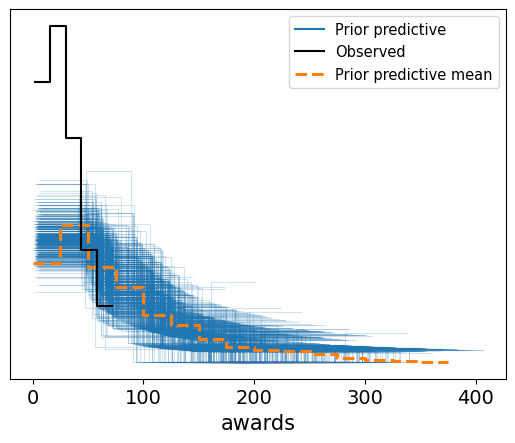

In [5]:
# prior predictive check
ax = az.plot_ppc(prior_predictive, group="prior", observed=True)

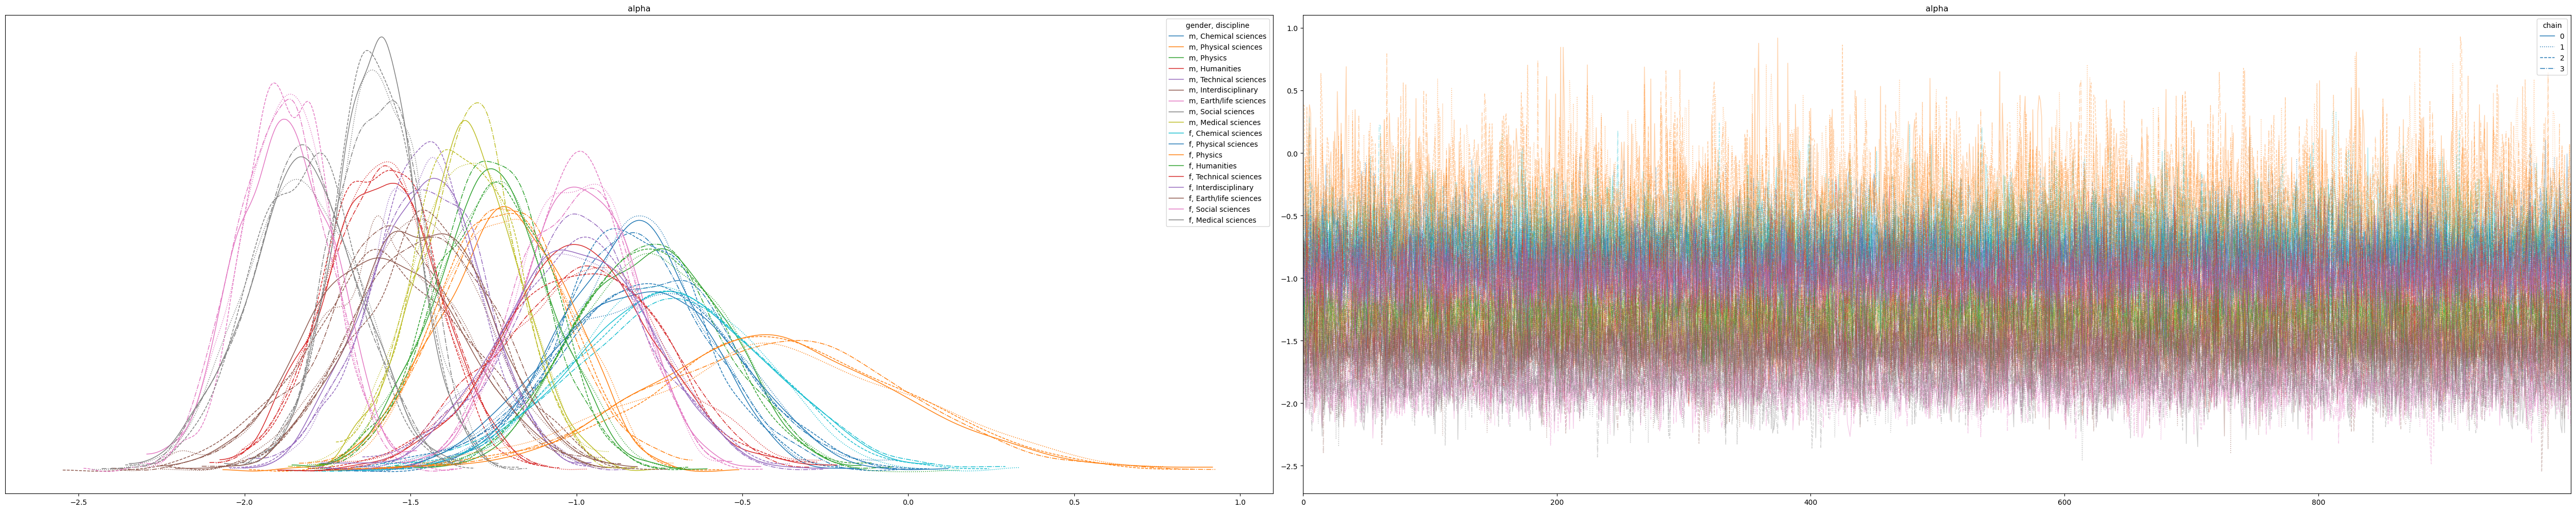

In [6]:
plot_trace(posterior, var_names=["alpha"], legend=True, figsize=(50,10))

In [7]:
az.summary(posterior)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"alpha[m, Chemical sciences]",-0.833,0.215,-1.229,-0.418,0.003,0.004,6756.0,2981.0,1.0
"alpha[m, Physical sciences]",-1.223,0.193,-1.582,-0.873,0.002,0.003,7457.0,2931.0,1.0
"alpha[m, Physics]",-0.784,0.226,-1.181,-0.352,0.003,0.004,6640.0,3050.0,1.0
"alpha[m, Humanities]",-1.590,0.166,-1.906,-1.292,0.002,0.003,6593.0,2569.0,1.0
"alpha[m, Technical sciences]",-1.461,0.170,-1.795,-1.154,0.002,0.003,6706.0,3170.0,1.0
"alpha[m, Interdisciplinary]",-1.572,0.235,-2.038,-1.154,0.002,0.004,8995.0,2594.0,1.0
"alpha[m, Earth/life sciences]",-1.004,0.171,-1.306,-0.676,0.002,0.003,7733.0,2824.0,1.0
"alpha[m, Social sciences]",-1.604,0.126,-1.847,-1.371,0.001,0.002,8014.0,3017.0,1.0
"alpha[m, Medical sciences]",-1.332,0.153,-1.612,-1.044,0.002,0.003,6841.0,2813.0,1.0
"alpha[f, Chemical sciences]",-0.719,0.291,-1.223,-0.150,0.003,0.006,8405.0,2586.0,1.0


                                       mean     sd  hdi_2.5%  hdi_97.5%  \
gender_contrast[Chemical sciences]   -0.026  0.076    -0.172      0.119   
gender_contrast[Physical sciences]   -0.084  0.067    -0.208      0.053   
gender_contrast[Physics]             -0.089  0.108    -0.316      0.111   
gender_contrast[Humanities]          -0.052  0.038    -0.122      0.027   
gender_contrast[Technical sciences]  -0.084  0.055    -0.194      0.020   
gender_contrast[Interdisciplinary]   -0.096  0.056    -0.199      0.018   
gender_contrast[Earth/life sciences]  0.080  0.046    -0.007      0.167   
gender_contrast[Social sciences]      0.035  0.024    -0.010      0.084   
gender_contrast[Medical sciences]     0.070  0.032     0.009      0.131   

                                      mcse_mean  mcse_sd  ess_bulk  ess_tail  \
gender_contrast[Chemical sciences]        0.001    0.001    7478.0    3127.0   
gender_contrast[Physical sciences]        0.001    0.001    7891.0    2856.0   
gender_co

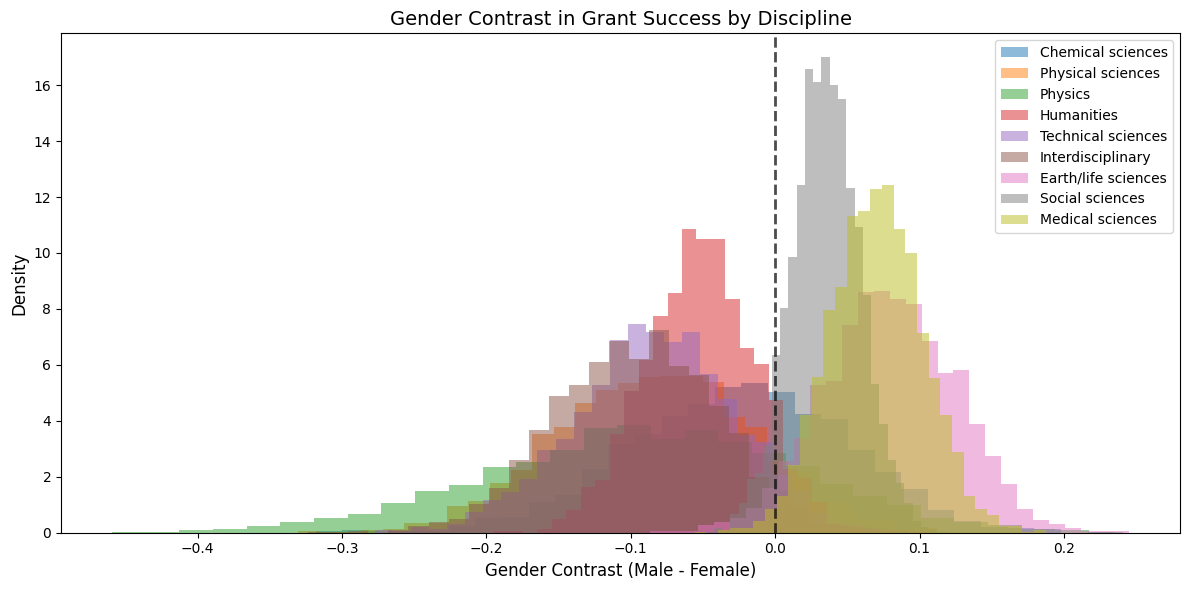

In [12]:
# Compute gender contrast using xarray
probs_m = 1 / (1 + np.exp(-posterior.posterior["alpha"].sel(gender="m")))
probs_f = 1 / (1 + np.exp(-posterior.posterior["alpha"].sel(gender="f")))
posterior.posterior["gender_contrast"] = probs_m - probs_f

# Summary
print(az.summary(posterior, var_names=["gender_contrast"], hdi_prob=0.95))

# Plot all distributions as histograms in one figure
fig, ax = plt.subplots(figsize=(12, 6))
disciplines = df["discipline"].unique().to_list()
colors = plt.cm.tab10(range(len(disciplines)))

for i, discipline in enumerate(disciplines):
    contrast_data = posterior.posterior["gender_contrast"].sel(discipline=discipline).values.flatten()
    ax.hist(contrast_data, bins=30, alpha=0.5, color=colors[i], label=discipline, density=True)

ax.axvline(x=0, color='black', linestyle='--', linewidth=2, alpha=0.7)
ax.set_xlabel('Gender Contrast (Male - Female)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Gender Contrast in Grant Success by Discipline', fontsize=14)
ax.legend()
plt.tight_layout()